# 01: Meet Tiny ImageNet

We will build our own UnCLe implementation one step at a time. First, understand what goes into a model: images and labels. This notebook only loads and explores data. No GPU is needed.

By the end, you should be able to explain a class ID, inspect an image, verify split sizes, and read the shape of a training batch.

In [1]:
from pathlib import Path
import sys

# Works when launched from this folder or the repository root.
HERE = Path.cwd()
if not (HERE / "data.py").is_file():
    HERE = HERE / "hypernetwork" / "uncle_from_scratch"
if not (HERE / "data.py").is_file():
    raise RuntimeError("Launch Jupyter from the repository root or uncle_from_scratch")
sys.path.insert(0, str(HERE.resolve()))

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
from data import DEFAULT_ROOT, TinyImageNet, prepare_data
from explore import class_counts, show_examples, pixel_statistics

SEED = 42
ROOT = DEFAULT_ROOT  # Change this to your extracted tiny-imagenet-200 folder.
DOWNLOAD = False    # True downloads the official archive if ROOT does not exist.
root = prepare_data(ROOT, download=DOWNLOAD)
print(root)

C:\LangChain\Algoverse\continual-learning\hypernetwork\data\tiny-imagenet-200


## 1. Inspect the files before loading tensors

`wnids.txt` lists the classes in this dataset. A WordNet ID identifies a category; `words.txt` maps IDs to readable descriptions and contains more entries than this dataset uses.

Training images normally live in `train/<class ID>/images/`. Validation images normally share `val/images/`, with labels in `val/val_annotations.txt`. The loader also accepts already rearranged class folders. We leave the files in place.

In [2]:
print("Top-level entries:", [p.name for p in sorted(root.iterdir())])
print("First five class IDs:", (root / "wnids.txt").read_text().split()[:5])
print("One validation annotation:")
print((root / "val" / "val_annotations.txt").read_text().splitlines()[0])

Top-level entries: ['test', 'train', 'val', 'wnids.txt', 'words.txt']
First five class IDs: ['n02124075', 'n04067472', 'n04540053', 'n04099969', 'n07749582']
One validation annotation:
val_0.JPEG	n03444034	0	32	44	62


## 2. Build a shared label mapping

A classifier needs integer labels. We sort the class IDs and assign labels from 0 upward. Both splits must use the same mapping: label 0 must mean the same category in training and validation.

A dataset stores image paths and labels. It opens an image only when indexed, so creating the dataset does not put all image pixels in memory.

In [3]:
train = TinyImageNet(root, split="train")
val = TinyImageNet(root, split="val")
assert train.class_to_idx == val.class_to_idx
print(f"Classes: {len(train.classes)}")
print(f"Training images: {len(train):,}; validation images: {len(val):,}")
for label in range(5):
    print(label, train.classes[label], train.class_names[label])

Classes: 200
Training images: 100,000; validation images: 10,000
0 n01443537 goldfish, Carassius auratus
1 n01629819 European fire salamander, Salamandra salamandra
2 n01641577 bullfrog, Rana catesbeiana
3 n01644900 tailed frog, bell toad, ribbed toad, tailed toad, Ascaphus trui
4 n01698640 American alligator, Alligator mississipiensis


## 3. Understand one image

The image on disk can have a different color mode. The loader converts every image to RGB so a batch always has three channels. A PIL image reports size as `(width, height)`; a NumPy image array uses `(height, width, channels)`.

On disk: RGB (64, 64)
Loaded: RGB (64, 64)
Array: (64, 64, 3) uint8
Label: 0 n01443537 goldfish, Carassius auratus


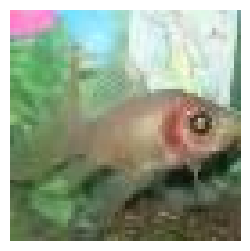

In [4]:
image, label = train[0]
with Image.open(train.samples[0][0]) as raw:
    print("On disk:", raw.mode, raw.size)
print("Loaded:", image.mode, image.size)
print("Array:", np.asarray(image).shape, np.asarray(image).dtype)
print("Label:", label, train.classes[label], train.class_names[label])
plt.figure(figsize=(3, 3))
plt.imshow(image)
plt.axis("off")
plt.show()

## 4. Check counts and class balance

The [Stanford description](https://cs231n.stanford.edu/reports/2015/pdfs/yle_project.pdf) specifies 200 classes, 500 training images per class and 50 validation images per class. Check these expectations against the local files. The public test split has no labels, so it cannot supply local classification accuracy.

train total: 100000 per-class min/max: 500 500
val total: 10000 per-class min/max: 50 50


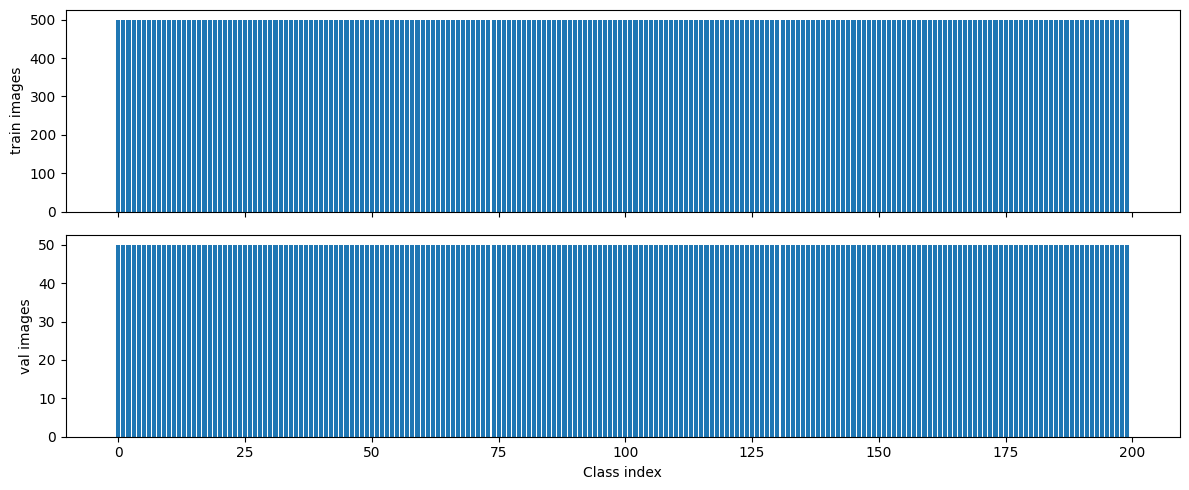

In [5]:
train_counts = class_counts(train)
val_counts = class_counts(val)
for name, counts in [("train", train_counts), ("val", val_counts)]:
    print(name, "total:", int(counts.sum()), "per-class min/max:", int(counts.min()), int(counts.max()))
assert len(train.classes) == 200, "Expected the complete 200-class dataset"
assert np.all(train_counts == 500), "Training counts differ from the official dataset"
assert np.all(val_counts == 50), "Validation counts differ from the official dataset"
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
for ax, counts, name in zip(axes, [train_counts, val_counts], ["train", "val"]):
    ax.bar(range(len(counts)), counts)
    ax.set_ylabel(f"{name} images")
axes[-1].set_xlabel("Class index")
plt.tight_layout()
plt.show()

## 5. Look at different classes

Each panel shows one training image from a different class. The seed makes the choices repeatable. At this resolution, look for small objects, cluttered backgrounds, and categories that could be hard to distinguish.

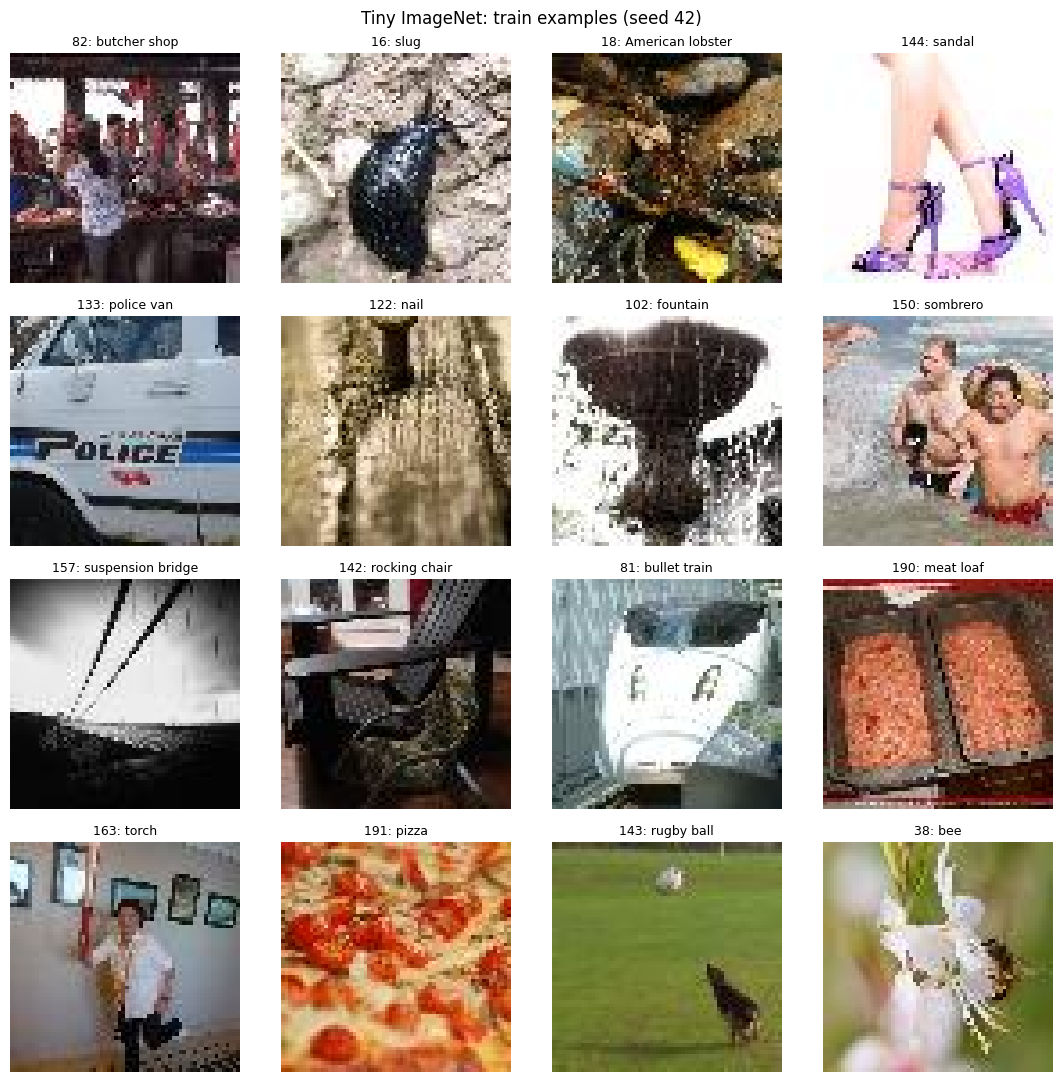

In [6]:
fig = show_examples(train, seed=SEED)
plt.show()

## 6. Measure pixels before choosing normalization

Estimate per-channel mean and standard deviation from a reproducible sample of training images, with pixels scaled to [0, 1]. These are sample estimates, not full-dataset constants. We accumulate pixel sums and squared sums; averaging image standard deviations would give a different quantity.

Use training data to choose preprocessing statistics. The mode and size counts below cover only this sample, not an integrity scan of every file.

In [7]:
stats = pixel_statistics(train, sample_size=2048, seed=SEED)
for key, value in stats.items():
    print(f"{key}: {value}")

sample_images: 2048
seed: 42
raw_modes: {'L': 39, 'RGB': 2009}
sizes: {'64x64': 2048}
rgb_mean: [0.47926835359311576, 0.4462029901205329, 0.39683617984547404]
rgb_std: [0.27931407732008506, 0.27130897769037177, 0.28238420039732104]


## 7. Turn images into a batch

`ToTensor()` converts an RGB image to a float tensor with shape `(channels, height, width)` and values in [0, 1]. A `DataLoader` stacks images into `(batch, channels, height, width)` and labels into `(batch,)`.

We keep `num_workers=0` for a simple first run on Windows and in notebooks. No augmentation or normalization is applied yet.

In [8]:
tensor_train = TinyImageNet(root, "train", transform=ToTensor())
loader = DataLoader(tensor_train, batch_size=32, shuffle=True, num_workers=0,
                    generator=torch.Generator().manual_seed(SEED))
images, labels = next(iter(loader))
print("Images:", images.shape, images.dtype)
print("Labels:", labels.shape, labels.dtype)
print("Pixel range:", images.min().item(), images.max().item())
assert images.shape == (32, 3, 64, 64)
assert labels.dtype == torch.int64
assert 0 <= images.min() and images.max() <= 1
assert 0 <= labels.min() and labels.max() < len(train.classes)

Images: torch.Size([32, 3, 64, 64]) torch.float32
Labels: torch.Size([32]) torch.int64
Pixel range: 0.0 1.0


## What we have established

We can load labeled images, keep class meanings consistent across splits, inspect visual examples, and build a batch. Before continuing, explain why a validation label must use the training mapping and why the test folder cannot be used to compute accuracy locally.

Next we can train a small CNN on a supervised baseline. After that, we can divide classes into tasks and introduce the hypernetwork and unlearning objectives.

To save the same exploration as PNG figures and JSON measurements, run `python explore.py` from this folder.